In [56]:
import pandas as pd

families_timedep = [
    'conficker',
    'corebot',
    'cryptolocker',
    'emotet',
    'gozi',
    'matsnu',
    'murofet',
    'necurs',
    'nymaim',
    'padcrypt',
    'qadars',
    'suppobox',
    'symmi'
]
families_timeindep = [
    'dircrypt',
    'fobber',
    'kraken',
    'pushdo',
    'pykspa',
    'ramdo',
    'ramnit',
    'ranbyus',
    'rovnix',
    'simda',
    'tinba',
    'vawtrak'
]

families = families_timedep + families_timeindep

In [3]:
df = pd.read_csv('./dac_csv_0.csv')

df

/var/folders/4s/h7p_rb6j4ts7ml0z0l5qj_x00000gn/T/ipykernel_54211/1135195788.py:1: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./dac_csv_0.csv')


,dn,year,family,tranco_rank,eps_none,eps_tld,eps_icann,eps_private,tld,icann,private
0,clynmk.com,2019.0,virut,NaN,0.000011,0.078256,0.976599,0.681374,com,NaN,NaN
1,nkidfd.com,2019.0,virut,NaN,0.000349,0.439126,0.003922,0.000652,com,NaN,NaN
2,guuoak.com,2019.0,virut,NaN,0.000027,0.905613,0.040848,0.983273,com,NaN,NaN
3,ndemka.com,2019.0,virut,NaN,0.000033,0.000323,0.448665,0.001936,com,NaN,NaN
4,stfuus.com,2019.0,virut,NaN,0.000035,0.029753,0.142515,0.306420,com,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
499995,cwaiorc.mx,2016.0,necurs,NaN,0.999418,0.999962,0.962577,0.987744,mx,NaN,NaN
499996,ximctqjacjbfxwjltf.mn,2016.0,necurs,NaN,1.000000,0.999995,1.000000,1.000000,mn,NaN,NaN
499997,trawexbrkyy.sx,2016.0,necurs,NaN,0.999994,0.247349,0.999502,0.999573,sx,NaN,NaN
499998,wnfwpnekcllbu.su,2016.0,necurs,NaN,0.999999,0.999974,0.999872,0.999997,su,NaN,NaN


/var/folders/4s/h7p_rb6j4ts7ml0z0l5qj_x00000gn/T/ipykernel_54211/1552688844.py:19: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  suffix = dfg[['family', 'icann', 'private']].groupby('family').sum()
/var/folders/4s/h7p_rb6j4ts7ml0z0l5qj_x00000gn/T/ipykernel_54211/1552688844.py:21: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  tpr = dfg[['family', 'tpr']].groupby('family').aggregate(['min', 'max', 'std', 'mean'])


,yearmin,yearmax,isna,icann,private,min,max,std,mean
family,,,,,,,,,
corebot,2015,2019,0,0,1065,0.995215,0.995392,0.000070,0.995304
cryptolocker,2013,2019,0,5787,0,0.984588,0.988030,0.001333,0.986572
gozi,2010,2019,0,0,0,0.264535,0.344000,0.025738,0.297103
matsnu,2014,2019,0,0,0,0.074841,0.333333,0.097422,0.148821
necurs,2013,2019,0,0,0,0.953309,0.959471,0.002422,0.956822
padcrypt,2016,2019,0,33,0,1.000000,1.000000,0.000000,1.000000
pushdo,2012,2019,0,0,0,0.640516,0.718750,0.023517,0.664571
qadars,2013,2019,0,0,0,0.894737,0.947784,0.018624,0.934576
ranbyus,2015,2019,0,0,0,0.990840,0.994421,0.001601,0.992899


year        family    tp          icann  private       tpr
                          count   sum <lambda> <lambda>          
5    2010.0          gozi   375   129        0        0  0.344000
10   2011.0          gozi   344    91        0        0  0.264535
16   2012.0          gozi   400   119        0        0  0.297500
19   2012.0        pushdo    32    23        0        0  0.718750
25   2013.0  cryptolocker  5890  5818      844        0  0.987776
..      ...           ...   ...   ...      ...      ...       ...
208  2019.0        pushdo  1015   663        0        0  0.653202
210  2019.0        qadars  1748  1652        0        0  0.945080
212  2019.0       ranbyus   717   713        0        0  0.994421
215  2019.0      suppobox  3479  2266        0        0  0.651337
217  2019.0         symmi    26    26        0       26  1.000000

[72 rows x 7 columns]

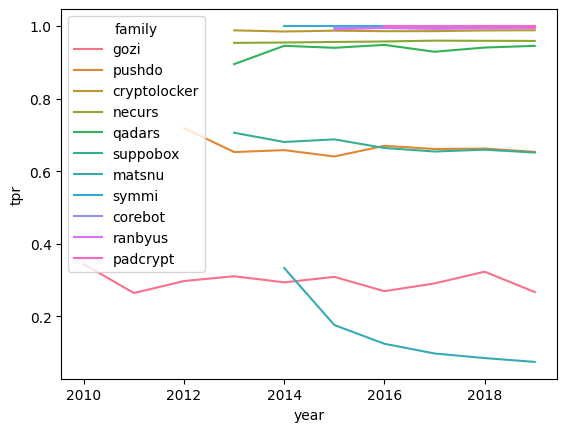

In [66]:
import seaborn

for nn in ['icann', 'gozi', 'tld', 'private']:
    df['tp'] = (df[f'eps_{nn}'] > 0.5) & (df['tranco_rank'].isna())

    dfg = df[['tp', 'year', 'family', 'icann', 'private']].groupby(['year', 'family']).aggregate({
        'tp': ['count', 'sum'],
        'icann': lambda x: (~x.isna()).sum(),
        'private': lambda x: (~x.isna()).sum()
    })

    dfg['tpr'] = dfg['tp', 'sum'] / dfg['tp', 'count']

    dfg = dfg.reset_index()

    year = dfg[['family', 'year']].groupby('family').aggregate(['min', 'max', lambda x: x.isna().sum()])
    year.columns = ['yearmin', 'yearmax', 'isna']
    year = year.astype(int)
    suffix = dfg[['family', 'icann', 'private']].groupby('family').sum()
    suffix.columns = [ 'icann', 'private' ]
    tpr = dfg[['family', 'tpr']].groupby('family').aggregate(['min', 'max', 'std', 'mean'])
    tpr = tpr.droplevel([0,1], axis=1)

    DF = year.join(suffix).join(tpr)

    display(DF.loc[DF.index.intersection(families)])

    dfg_in = dfg[dfg.family.apply(lambda x: x in families)]
    seaborn.lineplot(dfg_in, x='year', y='tpr', hue='family')

    display(dfg_in)

    break
    # print(nn, s.sum(), s.shape[0], s.sum()/s.shape[0])